In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"  # Limit JAX to use at most 20% of GPU memory
import jax

import jax.numpy as jnp
from temgym_core.components import Detector
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import (
    compute_Kv_from_voltage,
    compute_I0_Cf_from_focal_rotation
)
from temgym_core.gaussian import square_input_wave, run_to_end_vmapped, ElectromagneticLens
from temgym_core.components import RotatingLens
from temgym_core.run import run_to_end as run_to_end_for_abcd
from temgym_core.evaluate import evaluate_gaussians_jax_scan
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

%matplotlib widget



In [2]:
voltage = 200e3 # V
M1 = -100
M2 = -25
f1 = 1e-1
psi1 = np.pi # rad
f2 = 10e-1
psi2 = np.pi # rad

Kv = compute_Kv_from_voltage(voltage) # V
I1, Cf1 = compute_I0_Cf_from_focal_rotation(f1, psi1, Kv)
I2, Cf2 = compute_I0_Cf_from_focal_rotation(f2, psi2, Kv)

z1_L1, z2_L1 = calculate_z1_and_z2_from_M_and_f(M1, f1)
z1_L2, z2_L2 = calculate_z1_and_z2_from_M_and_f(M2, f2)
lens_z1 = np.abs(z1_L1)
lens_z2 = lens_z1 + np.abs(z2_L1) + np.abs(z1_L2)
detector_z = lens_z2 + np.abs(z2_L2)
lens1 = ElectromagneticLens(I0=I1, Cf=Cf1, z=lens_z1, Kv=Kv)
lens2 = ElectromagneticLens(I0=I2, Cf=Cf2, z=lens_z2, Kv=Kv)

input_aperture_width = 1e-6
input_image_shape = (512, 512)
input_window_width = input_aperture_width * 2
input_pixel_size = input_window_width / 512
input_detector = Detector(z=0, pixel_size=(input_pixel_size, input_pixel_size), shape=input_image_shape)

output_detector_width = 10e-3
output_image_shape = (512, 512)
output_pixel_size = output_detector_width / 512
output_detector = Detector(z=detector_z, pixel_size=(output_pixel_size, output_pixel_size), shape=output_image_shape)

input_rays = square_input_wave(input_aperture_width, waist=5e-9, voltage=voltage, overlap_factor=2.0)
input_aperture_image = evaluate_gaussians_jax_scan(input_rays, input_detector)

Text(0.5, 1.0, 'Input Aperture Image')

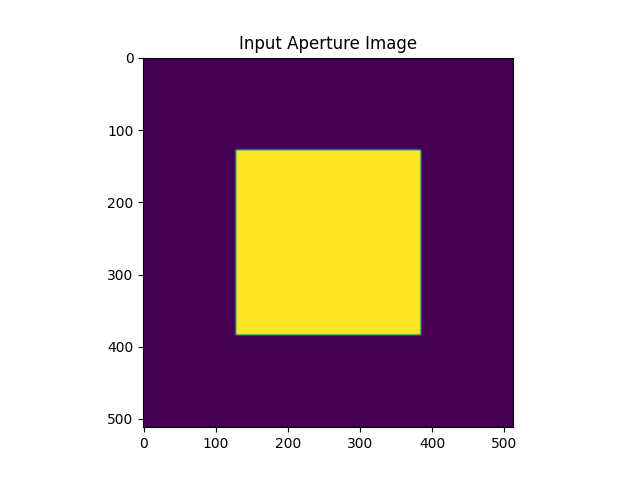

In [3]:

plt.figure()
plt.imshow(np.abs(input_aperture_image))
plt.title("Input Aperture Image")

In [4]:
model = [lens1, lens2, output_detector]
output_rays = run_to_end_vmapped(input_rays, model)
output_image = evaluate_gaussians_jax_scan(output_rays, output_detector)


Text(0.5, 1.0, 'Output Image')

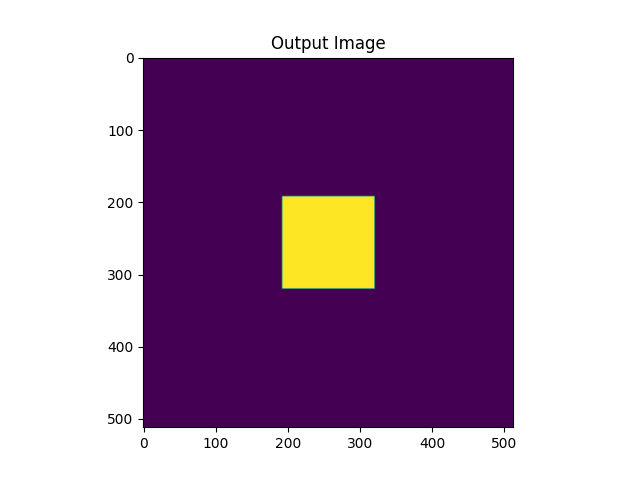

In [5]:
plt.figure()
plt.imshow(np.abs(output_image))
plt.title("Output Image")

In [6]:
import sympy as sp

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix, rotation_matrix

def build_abcd(dists, focals, rotations, xp=jnp):
    """Construct ABCD matrix for N-lens system.

    dists: length N+1, focals: length N
    M = P(d_{N+1}) L_N ... L_1 P(d_1)
    """
    M = propagation_matrix(dists[-1], xp=xp)
    for i in reversed(range(len(focals))):
        M = M @ lens_matrix(focals[i], xp=xp)
        M = M @ rotation_matrix(rotations[i], xp=xp)
        M = M @ propagation_matrix(dists[i], xp=xp)
    return M


def compute_AB(dists, focals, rotations):
    M = build_abcd(dists, focals, rotations, xp=jnp)
    return M[0, 0], M[0, 1]


def create_wobbled_lenses(lenses, wobble_vector):
    """Create wobbled versions of lenses by applying relative current perturbation.

    Args:
        lenses: list of ElectromagneticLens objects
        wobble_vector: array of shape (n_lenses,), relative perturbations w_i
                      where I0_wobbled = I0 * (1 + w_i)

    Returns:
        list of new ElectromagneticLens objects with wobbled I0 values
    """
    wobbled = []
    for i, lens in enumerate(lenses):
        I0_wobbled = lens.I0 * (1.0 + wobble_vector[i])
        # Create new lens with wobbled I0, keeping Cf, Kv the same
        wobbled_lens = ElectromagneticLens(
            I0=I0_wobbled, 
            Cf=lens.Cf, 
            z=lens.z,
            Kv=lens.Kv
        )
        wobbled.append(wobbled_lens)
    return wobbled


def generate_wobble_grid(wobble_scale, n_wobbles_per_lens):
    """Generate uniformly-spaced wobble values around ±wobble_scale.

    For n_wobbles_per_lens=6 and wobble_scale=0.05:
        Returns [-0.05, -0.03, -0.01, 0.01, 0.03, 0.05]

    Args:
        wobble_scale: half-width of wobble range (e.g., 0.05 for ±5%)
        n_wobbles_per_lens: number of wobble points to generate

    Returns:
        array of shape (n_wobbles_per_lens,), uniformly spaced wobbles
    """
    # Generate symmetric wobbles around 0, excluding 0
    if n_wobbles_per_lens % 2 == 0:
        # Even: symmetric around 0
        half_n = n_wobbles_per_lens // 2
        neg_wobbles = -np.linspace(wobble_scale / half_n, wobble_scale, half_n)
        pos_wobbles = np.linspace(wobble_scale / half_n, wobble_scale, half_n)
        wobbles_1d = np.concatenate([neg_wobbles, pos_wobbles])
    else:
        # Odd: include 0 in the middle
        half_n = n_wobbles_per_lens // 2
        neg_wobbles = -np.linspace(wobble_scale / (half_n + 1), wobble_scale, half_n)
        pos_wobbles = np.linspace(wobble_scale / (half_n + 1), wobble_scale, half_n)
        wobbles_1d = np.concatenate([neg_wobbles, [0.0], pos_wobbles])

    return wobbles_1d


def generate_wobble_individual_ensemble(input_rays, nominal_lenses, output_detector, 
                                        wobble_scale, n_wobbles_per_lens):
    """Generate ensemble by varying each lens individually (one at a time).

    For 2 lenses with n_wobbles_per_lens=6:
        Total images: 6 + 6 = 12 
        First 6: vary lens 0, lens 1 at nominal
        Next 6: vary lens 1, lens 0 at nominal

    Args:
        input_rays: Gaussian beam rays at input
        nominal_lenses: list of nominal ElectromagneticLens objects
        output_detector: output Detector
        wobble_scale: half-width of wobble range for each lens (e.g., 0.05 for ±5%)
        n_wobbles_per_lens: number of wobble points per lens (e.g., 6)

    Returns:
        tuple: (images_array, lens_indices, wobble_indices, wobble_values, abcd_matrices)
               - images_array: shape (n_total, height, width), complex valued
               - lens_indices: shape (n_total,), which lens was perturbed
               - wobble_indices: shape (n_total,), index into wobble grid for this lens
               - wobble_values: shape (n_total,), actual wobble value applied
               - abcd_matrices: shape (n_total, 2, 2), ABCD matrix for each configuration
    """
    n_lenses = len(nominal_lenses)

    # Generate 1D wobble grid
    wobble_grid_1d = generate_wobble_grid(wobble_scale, n_wobbles_per_lens)

    images = []
    lens_indices_list = []
    wobble_indices_list = []
    wobble_values_list = []
    abcd_matrices_list = []

    # For each lens
    for lens_idx in range(n_lenses):
        # For each wobble value
        for wobble_idx, wobble_val in enumerate(wobble_grid_1d):
            # Create wobble vector (all zeros except for this lens)
            wobble_vector = np.zeros(n_lenses)
            wobble_vector[lens_idx] = wobble_val

            # Create wobbled lenses
            wobbled_lenses = create_wobbled_lenses(nominal_lenses, wobble_vector)

            zs = []
            fs = []
            phi = []
            # Calculate ABCD of wobbled lenses
            for lens in wobbled_lenses:
                zs.append(lens.z)
                fs.append(lens.focal_length)
                phi.append(lens.rotation_angle)

            zs.append(output_detector.z)
            zs = [zs[0]] + list(np.diff(zs))  # Convert to distances between elements

            ABCD = build_abcd(zs, fs, phi, xp=jnp)
            abcd_matrices_list.append(np.array(ABCD))

            # Propagate rays through wobbled system
            model = wobbled_lenses + [output_detector]
            output_rays_wobbled = run_to_end_vmapped(input_rays, model)

            # Evaluate image
            image_wobbled = evaluate_gaussians_jax_scan(output_rays_wobbled, output_detector)
            images.append(np.array(image_wobbled))

            lens_indices_list.append(lens_idx)
            wobble_indices_list.append(wobble_idx)
            wobble_values_list.append(wobble_val)

    images_array = np.array(images)
    lens_indices_array = np.array(lens_indices_list)
    wobble_indices_array = np.array(wobble_indices_list)
    wobble_values_array = np.array(wobble_values_list)
    abcd_matrices_array = np.array(abcd_matrices_list)

    return (
        images_array,
        lens_indices_array,
        wobble_indices_array,
        wobble_values_array,
        abcd_matrices_array,
    )


In [7]:
# Generate individual wobble ensemble (one lens at a time)
wobble_scale = 0.2
n_wobbles_per_lens = 3

print(f"Generating individual wobble ensemble with wobble_scale=±{wobble_scale*100:.1f}% and {n_wobbles_per_lens} wobbles per lens")

ensemble_images, lens_indices, wobble_indices, wobble_values, abcd_matrices = generate_wobble_individual_ensemble(
    input_rays,
    nominal_lenses=[lens1, lens2],
    output_detector=output_detector,
    wobble_scale=wobble_scale,
    n_wobbles_per_lens=n_wobbles_per_lens
)

print(f"\nEnsemble shape: {ensemble_images.shape}")
print(f"Total images: {len(ensemble_images)}")

# Show wobble grid
wobble_grid_1d = generate_wobble_grid(wobble_scale, n_wobbles_per_lens)
print(f"\nWobble grid (×100%):")
print(f"  {wobble_grid_1d * 100}")
print(f"  range=[{wobble_grid_1d.min()*100:.2f}%, {wobble_grid_1d.max()*100:.2f}%]")

# Show breakdown by lens
for lens_idx in range(len([lens1, lens2])):
    mask = lens_indices == lens_idx
    print(f"\nLens {lens_idx+1}: {np.sum(mask)} images")
    print(f"  Wobbles: {wobble_values[mask]}")

print("\nABCD matrices per configuration:")
for idx, abcd in enumerate(abcd_matrices):
    lens_idx = int(lens_indices[idx])
    wobble_idx = int(wobble_indices[idx])
    wobble_val = float(wobble_values[idx])
    a_val = float(abcd[0, 0])
    b_val = float(abcd[0, 1])
    effective_defocus = b_val / a_val
    print(
        f"[{idx:03d}] lens={lens_idx+1}, wobble_idx={wobble_idx}, wobble={wobble_val:+.4f} -> "
        f"A={a_val:.6e}, B={b_val:.6e}, effective_defocus={effective_defocus:.6e}"
    )


Generating individual wobble ensemble with wobble_scale=±20.0% and 3 wobbles per lens

Ensemble shape: (6, 512, 512)
Total images: 6

Wobble grid (×100%):
  [-10.   0.  10.]
  range=[-10.00%, 10.00%]

Lens 1: 3 images
  Wobbles: [-0.1  0.   0.1]

Lens 2: 3 images
  Wobbles: [-0.1  0.   0.1]

ABCD matrices per configuration:
[000] lens=1, wobble_idx=0, wobble=-0.1000 -> A=1.843345e+03, B=-6.782555e+02, effective_defocus=-3.679482e-01
[001] lens=1, wobble_idx=1, wobble=+0.0000 -> A=2.500000e+03, B=-2.842171e-13, effective_defocus=-1.136868e-16
[002] lens=1, wobble_idx=2, wobble=+0.1000 -> A=2.959966e+03, B=9.952135e+02, effective_defocus=3.362247e-01
[003] lens=2, wobble_idx=0, wobble=-0.1000 -> A=9.099667e+02, B=-1.944085e-01, effective_defocus=-2.136435e-04
[004] lens=2, wobble_idx=1, wobble=+0.0000 -> A=2.500000e+03, B=-2.842171e-13, effective_defocus=-1.136868e-16
[005] lens=2, wobble_idx=2, wobble=+0.1000 -> A=3.932052e+03, B=2.316896e-01, effective_defocus=5.892332e-05


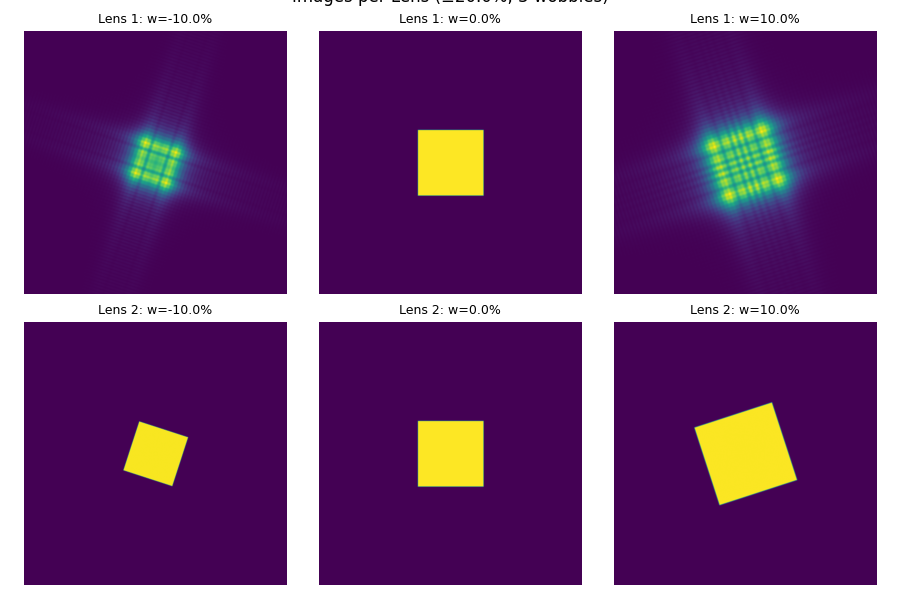

In [8]:
# Visualize all images per lens (no ensemble stats)
n_lenses = len(np.unique(lens_indices))
n_cols = n_wobbles_per_lens
fig, axes = plt.subplots(n_lenses, n_cols, figsize=(3 * n_cols, 3 * n_lenses))
if n_cols == 1:
    axes = axes[:, np.newaxis]  # Ensure axes is 2D for consistent indexing
    
for lens_idx in range(n_lenses):
    lens_mask = lens_indices == lens_idx
    lens_images = ensemble_images[lens_mask]
    lens_wobbles = wobble_values[lens_mask]
    for j in range(n_cols):
        ax = axes[lens_idx, j] if n_lenses > 1 else axes[j]
        ax.imshow(np.abs(lens_images[j]))
        ax.set_title(f"Lens {lens_idx+1}: w={lens_wobbles[j]*100:.1f}%", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.suptitle(
    f"Images per Lens (±{wobble_scale*100:.1f}%, {n_wobbles_per_lens} wobbles)",
    fontsize=12,
    y=1.02
)
plt.show()


## Image-space fitting (resample + rotate + defocus)

In [9]:
from temgym_core.constants import energy2wavelength
from temgym_core.utils import FresnelPropagator
import jax.scipy.ndimage as jndimage
import optax

# Replace with your known object image and its pixel size
known_object_image = jnp.abs(input_aperture_image) ** 2
known_object_pixel_size = input_pixel_size

# Target stack for fitting (intensity images on detector)
image_targets_raw = jnp.abs(jnp.asarray(ensemble_images)) ** 2
if image_targets_raw.ndim == 2:
    image_targets_raw = image_targets_raw[None, ...]

# Per-image normalization to remove global scale (normalize by max value)
image_targets = image_targets_raw / jnp.max(image_targets_raw, axis=(1, 2), keepdims=True)


def defocus_field(intensity_image, det_window_width, wavelength, defocus):
    """Apply FFT-based defocus."""
    # Prevent negative values and compute amplitude
    amplitude = jnp.sqrt(jnp.maximum(intensity_image, 1e-12))
    # Use complex128 for better numerical stability
    field = amplitude.astype(jnp.complex128)

    # Apply Fresnel propagation with clipped defocus to avoid numerical issues
    field_defocused = FresnelPropagator(field, det_window_width, wavelength, defocus)

    # Return intensity with small epsilon to avoid zeros
    intensity = jnp.maximum(jnp.abs(field_defocused) ** 2, 1e-12)
    return intensity


def normalize_image(image):
    epsilon = 1e-12
    max_val = jnp.max(image)
    return image / jnp.maximum(max_val, epsilon)


def focus_metric_lapvar(image):
    img = normalize_image(image)
    lap = (
        -4.0 * img
        + jnp.roll(img, 1, axis=0)
        + jnp.roll(img, -1, axis=0)
        + jnp.roll(img, 1, axis=1)
        + jnp.roll(img, -1, axis=1)
    )
    return jnp.var(lap)


def focus_metric_tenengrad(image):
    img = normalize_image(image)
    gx = jnp.roll(img, -1, axis=1) - jnp.roll(img, 1, axis=1)
    gy = jnp.roll(img, -1, axis=0) - jnp.roll(img, 1, axis=0)
    return jnp.mean(gx ** 2 + gy ** 2)


def compute_focus_metric(image, mode):
    if mode == "lapvar":
        return focus_metric_lapvar(image)
    if mode == "tenengrad":
        return focus_metric_tenengrad(image)
    raise ValueError(f"Unknown focus metric: {mode}")


def refocus_intensity(intensity_image, det_window_width, wavelength, defocus):
    return defocus_field(intensity_image, det_window_width, wavelength, -defocus)


def estimate_defocus_sharpness(
    target_intensity,
    det_window_width,
    wavelength,
    *,
    defocus_range=(-1e-3, 1e-3),
    n_grid=41,
    n_steps=200,
    lr=1e-2,
    metric="tenengrad",
):
    d_min, d_max = defocus_range
    grid = jnp.linspace(d_min, d_max, n_grid)

    def focus_score(d):
        refocused = refocus_intensity(target_intensity, det_window_width, wavelength, d)
        return compute_focus_metric(refocused, metric)

    scores = jax.vmap(focus_score)(grid)
    best_idx = jnp.argmax(scores)
    defocus = jnp.array(grid[best_idx], dtype=jnp.float64)

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(lr),
    )
    opt_state = optimizer.init(defocus)

    @jax.jit
    def step(defocus, opt_state):
        def loss_fn(d):
            return -focus_score(d)

        loss = loss_fn(defocus)
        grad = jax.grad(loss_fn)(defocus)
        updates, opt_state = optimizer.update(grad, opt_state, defocus)
        defocus = optax.apply_updates(defocus, updates)
        defocus = jnp.clip(defocus, d_min, d_max)
        return defocus, opt_state, loss

    losses = []
    for _ in range(n_steps):
        defocus, opt_state, loss = step(defocus, opt_state)
        losses.append(loss)

    return defocus, grid, scores, jnp.stack(losses) if losses else jnp.array([])


# Forward model: resample -> rotate -> defocus
wavelength = energy2wavelength(voltage)
output_detector_width = output_detector.pixel_size[0] * output_image_shape[0]

RUN_DEFOCUS_SHARPNESS = True
if RUN_DEFOCUS_SHARPNESS:
    target = image_targets[0]
    best_defocus, defocus_grid, focus_scores, focus_losses = estimate_defocus_sharpness(
        target,
        output_detector_width,
        wavelength,
        defocus_range=(-1000, 1000),
        n_grid=51,
        n_steps=1000,
        lr=1e-3,
        metric="lapvar",
    )
    print(f"Sharpness best defocus: {float(best_defocus):.6e} m")


Sharpness best defocus: 5.125953e-03 m


Text(0.5, 1.0, 'Defocused Image (best defocus=5.13e-03 m)')

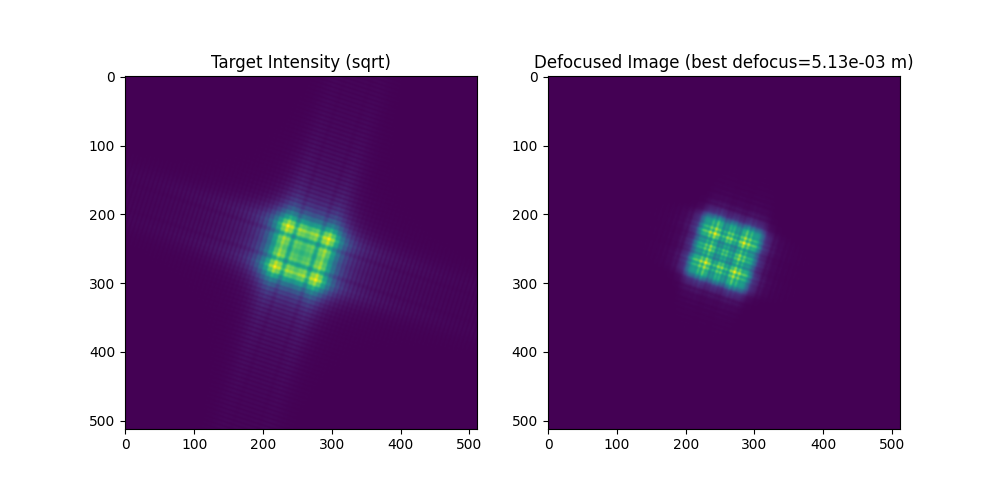

In [33]:
defocused_image = refocus_intensity(target, input_aperture_width, wavelength, 7e-4)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.sqrt(target))
axes[0].set_title("Target Intensity (sqrt)")
axes[1].imshow(np.abs(defocused_image))
axes[1].set_title(f"Defocused Image (best defocus={float(best_defocus):.2e} m)")

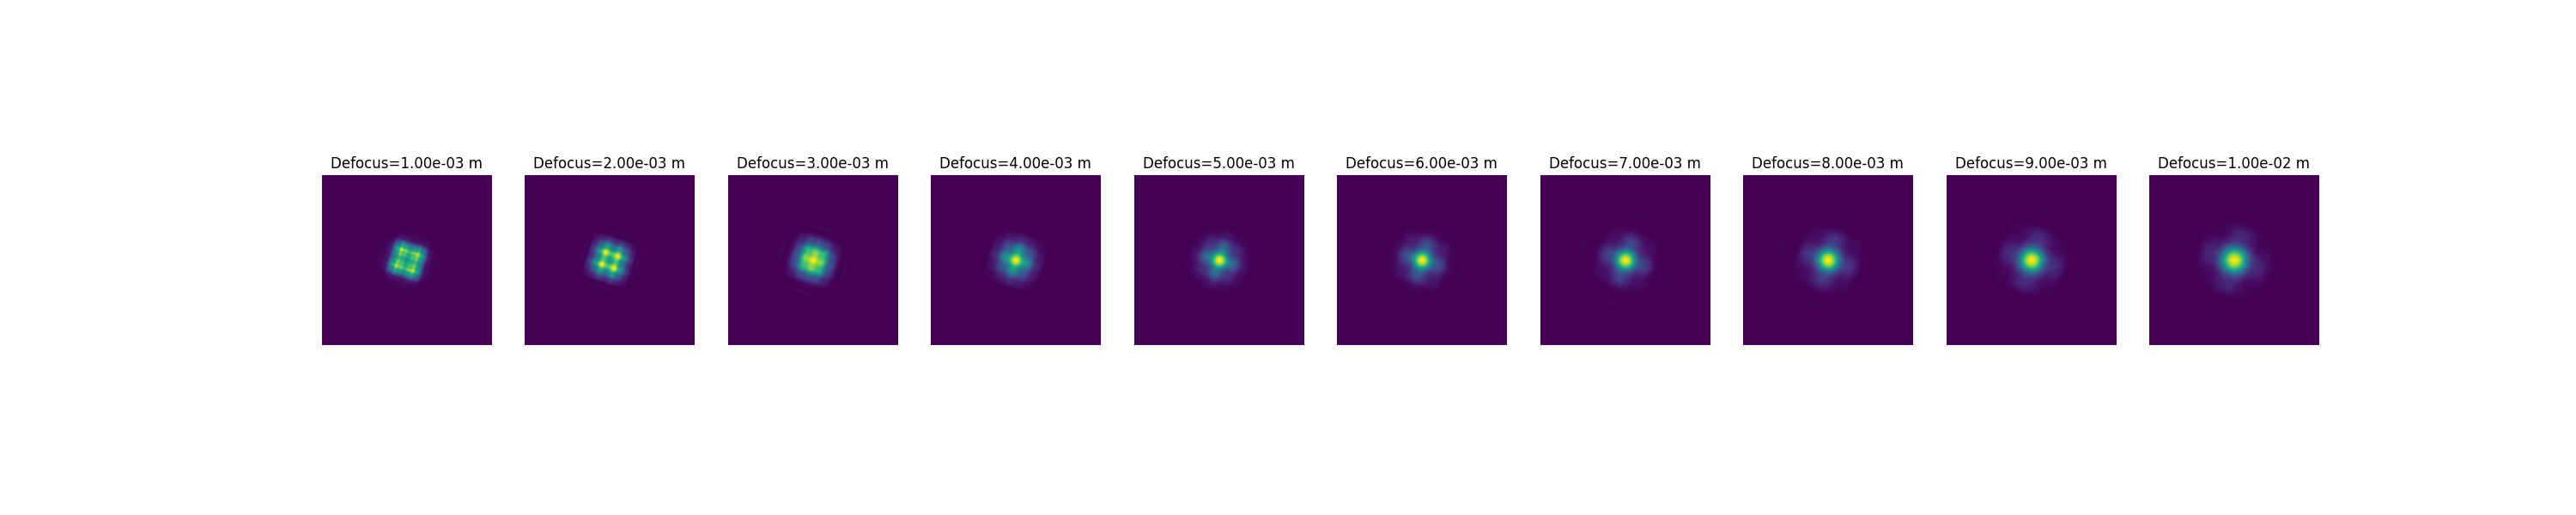

In [60]:
out_image = FresnelPropagator(target, input_aperture_width, wavelength, 0.7e-3)

n = 10
defocus_range = [1e-3, 1.0e-2]
d_min, d_max = defocus_range
grid = jnp.linspace(d_min, d_max, n)
images = jax.vmap(refocus_intensity, in_axes=(None, None, None, 0))(target, input_aperture_width, wavelength, grid)


fig, axes = plt.subplots(1, n, figsize=(3 * n, 6))
for i in range(n):
    axes[i].imshow(np.abs(images[i]))
    axes[i].set_title(f"Defocus={grid[i]:.2e} m")
    axes[i].axis("off")